# Segmental parameters for non-obese
A system of axes has been defined for each segment, with an origin at the segment mass center, while axes have been aligned with approximate body axes: anteroposterior (x), vertical (y), and mediolateral (z). The corresponding result for the position of the mass center for head and hand is measured at the center and the mass center for thigh is measured from the upper cross section of the thigh lower part. The other segmants measured from the upper cross section of each segment. The measurements are taken with positive values indicating anterior (forward), upward, and lateral (sideways) directions.

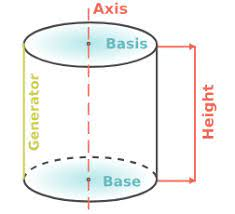

Head+Neck (Ellipsoid)

Upper torso (Frustum of elliptical cone)

Middle torso (Frustum of elliptical cone)

Lower torso (Frustum of elliptical cone + elliptical cone)

Thigh  (elliptical cone + Frustum of elliptical cone) 

Shank (Frustum of elliptical cone)

Foot (Frustum of elliptical cone)

Upper arm (Frustum of elliptical cone)

Lower arm (Frustum of elliptical cone)

Hand (Ellipsoid)



In [743]:
# Import Necessary Modules
import glob
import matplotlib.pyplot as plt
from skimage import io
import numpy as np
import math
%matplotlib inline

## 1. Head+Neck (Ellipsoid)
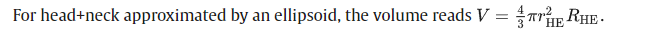
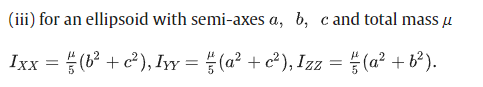

Reference:
Nikolova, Gergana Stefanova, and Yuli Emilov Toshev. "Estimation of male and female body segment parameters of the Bulgarian population using a 16-segmental mathematical model." Journal of biomechanics 40.16 (2007): 3700-3707.


Input parameters: Head_circumference + Head_length + head_mass

In [744]:
head_circumference=57.33
head_length=24.29305825

head_mass = 5.070034541

Mass, COM, and MOI for Head

In [745]:
def ellipsoid_inertia(R, r, h, m):
    Ixx = (1/5) * m * (R**2 + h**2)
    Iyy = (1/5) * m * (r**2 + R**2)
    Izz = (1/5) * m * (r**2 + h**2)
    return Ixx, Iyy, Izz

In [746]:
import numpy as np

# Ellipsoid parameters for head and neck
R = head_circumference/(2 * math.pi) # Head circumference
r = head_circumference/(2 * math.pi) # Head circumference
h = head_length/2 # Head length
head_mass = 5.070034541
m=head_mass

# Center of mass of ellipsoid (at the center)
center_of_mass_head_Y =  0
center_of_mass_head_X =  0
center_of_mass_head_Z =  0

# Inertia of ellipsoid
Ixx_head, Iyy_head, Izz_head = ellipsoid_inertia(r, R, h, m)


print(f"Head and Neck -  Mass: {head_mass:.2f}, Center of Mass(X): {center_of_mass_head_X}, Center of Mass(Y): {center_of_mass_head_Y}, Center of Mass(Z): {center_of_mass_head_Z},(Ixx: {Ixx_head}, Iyy: {Iyy_head}, Izz: {Izz_head})")



Head and Neck -  Mass: 5.07, Center of Mass(X): 0, Center of Mass(Y): 0, Center of Mass(Z): 0,(Ixx: 234.02466755212734, Iyy: 168.8398883349738, Izz: 234.02466755212734)


## 2. Upper Torso Upper torso (Frustum of elliptical cone)
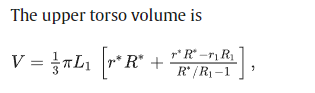
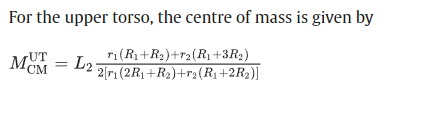
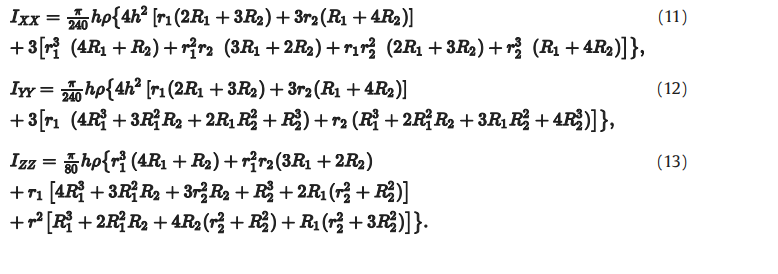


Reference:
Nikolova, Gergana Stefanova, and Yuli Emilov Toshev. "Estimation of male and female body segment parameters of the Bulgarian population using a 16-segmental mathematical model." Journal of biomechanics 40.16 (2007): 3700-3707.

Input parameters: Neckbase_circumference, Shoulder_breadth, Chest_depth, Chest_breadth, upper_torso_mass, upper_torso (length), middle_torso (length), shoulderwaistlen (length)


In [747]:
# Parameters for upper torso (upper part)
Neckbase_circumference= 42.56051158
Shoulder_breadth= 41.58
Chest_depth = 23.94
uppertorso_length= 23.1068407
middletorso_length= 23.62299232
shoulderwaistlen= 38.41019798


# Parameters for upper torso (lower part)
Shoulder_breadth= 41.58
Chest_depth = 23.94
Chest_circumference = 101.8232079
Chest_breadth= 28.50779903
Chest_depth = 23.94

uppertorso_mass = 15.6765

Mass, COM, and MOI for Torso

In [748]:
import numpy as np

def calculate_axes (circumference, diameter):
        """Calculate the semi-major and semi-minor axes from circumference and one axis diameter."""
        semi_major_axis = diameter / 2
        semi_minor_axis = (circumference / (2 * math.pi))**2 - semi_major_axis**2
        semi_minor_axis = math.sqrt(semi_minor_axis) if semi_minor_axis > 0 else semi_major_axis
        return semi_major_axis, semi_minor_axis


def calculate_center_of_mass(h, r1, R1, r2, R2):
    # Calculate the center of mass using the given formula
    center_of_mass = (h * (r1 * (R1 + R2) + r2 * (R1 + 3 * R2))) / (2 * (r1 * (2 * R1 + R2) + r2 * (R1 + 2 * R2)))
    return center_of_mass




def frustum_inertia(r1, R1, r2, R2, density, h):
    """
    Calculate the moments of inertia for a frustum of a right elliptical cone.
    
    Parameters:
    r1 (float): Semi-minor axis of the upper base ellipse
    R1 (float): Semi-major axis of the upper base ellipse
    r2 (float): Semi-minor axis of the lower base ellipse
    R2 (float): Semi-major axis of the lower base ellipse
    density (float): Density of the material
    h (float): Height of the frustum
    
    Returns:
    tuple: (Ixx, Iyy, Izz) moments of inertia for the frustum
    """
    volume = (1/3) * np.pi * h * (R1 * r1 + R2 * r2 + np.sqrt(R1 * r1 * R2 * r2))
    M = volume*density 
    Ixx= (np.pi / 240) * density * h * (
            4*h**2 * (r1*(2*R1 + 3*R2) + 3*r2*(R1 + 4*R2)) + 
            3 * (r1 * (4*R1**3 + 3*R1**2*R2 + 2*R1*R2**2 + R2**3) + 
                 r2 * (R1**3 + 2*R1**2*R2 + 3*R1*R2**2 + 4*R2**3)))
        

    Iyy = (np.pi / 80) * density * h * (
            r1**3 * (4*R1 + R2) + r1**2 * r2 * (3*R1 + 2*R2) + 
            r1 * (4*R1**3 + 3*R1**2*R2 + 3*r2**2*R2 + R2**3 + 2*R1*(r2**2 + R2**2)) + 
            r2 * (R1**3 + 2*R1**2*R2 + 4*R2*(r2**2 + R2**2) + R1*(r2**2 + 3*R2**2)))

    Izz = (np.pi / 240) * density * h * (4*h**2 * (r1*(2*R1 + 3*R2) + 3*r2*(R1 + 4*R2)) + 
                                       3 * (r1**3 * (4*R1 + R2) + r1**2 * r2 * (3*R1 + 2*R2) + 
                                            r1 * r2**2 * (2*R1 + 3*R2) + r2**3 * (R1 + 4*R2)))
    com = (h * (r1 * (R1 + R2) + r2 * (R1 + 3 * R2))) / (2 * (r1 * (2 * R1 + R2) + r2 * (R1 + 2 * R2)))
    
    Ixx= Ixx-(M*com**2)
    Izz= Izz-(M*com**2)
    
    return Ixx, Iyy, Izz

def elliptical_cone_inertia(R1, r1, h, m):
    
    Ixx = (3 * m / 20) * (4 * R1**2 + h**2)
    Iyy = (3 * m / 10) * (r1**2 + R1**2)
    Izz = (3 * m / 20) * (4 * r1**2 + h**2)
    com = (1/4) *h
    Ixx= Ixx-(m*com**2)
    Izz= Izz-(m*com**2)
    return Ixx, Iyy, Izz


##  Combined Inertia Properties (neck base~chest): The parallel axis theorem

In [749]:
import numpy as np

def combine_segments(segment1, segment2):
    """
    Combine two segments using mass, center of mass (COM), and inertia properties.
    Implements the Parallel Axis Theorem for adjusting inertia when the COM is shifted.

    Parameters:
    - segment1 (dict): Properties of the first segment (mass, COM, inertia tensor).
    - segment2 (dict): Properties of the second segment (mass, COM, inertia tensor).

    Returns:
    - dict: Combined segment properties (mass, COM, inertia tensor).
    """
    # Calculate the mass of the resulting segment
    combined_mass = segment1['mass'] +  segment2['mass']
    
    if combined_mass == 0:
        raise ValueError("Combined mass is zero, division by zero in COM calculation.")

    # Calculate the center of mass (COM) of the resulting segment
    r1 = np.array(segment1['com'])  # Original COM for segment 1
    r2 = np.array(segment2['com'])  # Original COM for segment 2
    combined_com = (segment1['mass'] * r1 + segment2['mass'] * r2) / combined_mass

    # Calculate the moments of inertia of the resulting segment
    I1 = np.array(segment1['inertia'])  # Inertia tensor for segment 1
    I2 = np.array(segment2['inertia'])  # Inertia tensor for segment 2

    # Compute relative position of COM for each segment
    r1_relative = r1 - combined_com
    r2_relative = r2 - combined_com

    # Apply the Parallel Axis Theorem to X and Z components only
    I_combined = np.zeros((3, 3))
    # X-component
    I_combined[0, 0] = (
        I1[0, 0] + I2[0, 0] + segment1['mass'] * (r1_relative[1]**2) + segment2['mass'] * (r2_relative[1]**2) + segment1['mass'] * (r1_relative[2]**2) + segment2['mass'] * (r2_relative[2]**2)
    )  
    # Y-component
    I_combined[1, 1] = (
        I1[1, 1] + I2[1, 1] + segment1['mass'] * (r1_relative[0]**2) + segment2['mass'] * (r2_relative[0]**2) + segment1['mass'] * (r1_relative[2]**2) + segment2['mass'] * (r2_relative[2]**2)
    )  
    # Z-component
    I_combined[2, 2] = (
        I1[2, 2] + I2[2, 2] + segment1['mass'] * (r1_relative[0]**2) + segment2['mass'] * (r2_relative[0]**2) + segment1['mass'] * (r1_relative[1]**2) + segment2['mass'] * (r2_relative[1]**2)
    ) 
   
    # Check for negative moments of inertia and issue a warning
    if np.any(I_combined < 0):
        print("Warning: Negative moments of inertia detected. Results may be physically implausible.")
        # Optional: Clamp negative values to zero
        I_combined[I_combined < 0] = 0

    # Return the combined segment properties
    return {
        'mass': combined_mass,
        'com': combined_com,
        'inertia': I_combined
        
    }


In [750]:
# Parameters for upper torso (upper part)

R1_upper = Neckbase_circumference/(2 * math.pi) # Neck radius
r1_upper = Neckbase_circumference/(2 * math.pi) # Neck radius
#R2, r2 = calculate_axes(Shoulder_circumference, Shoulder_breadth) 
R2_upper, r2_upper = Shoulder_breadth/2, Chest_depth/2
# R1= Shoulder radius semi_major_axis  
# r1= Shoulder radius semi_minor_axis 
necK_shoulder = uppertorso_length+middletorso_length-shoulderwaistlen # height
h1 = necK_shoulder # height

# Volume of elliptical frustum
volume_uppertorso_upper = (1/3) * np.pi * h1 * (R1_upper * r1_upper + R2_upper * r2_upper + np.sqrt(R1_upper * r1_upper * R2_upper * r2_upper))
center_of_mass_uppertorso_upper =calculate_center_of_mass(h1, r1_upper, R1_upper, r2_upper, R2_upper)
# Parameters for upper torso (lower part)

R1_lower, r1_lower = Shoulder_breadth/2, Chest_depth/2
#R1, r1 = calculate_axes(Shoulder_circumference, Shoulder_breadth) 
# R1= Shoulder radius semi_major_axis  
# r1= Shoulder radius semi_minor_axis 

#R2, r2 = calculate_axes(Chest_circumference, Chest_breadth) 
 # R2=Chest radius semi_major_axis  
 # r2=Chest radius semi_minor_axis  
R2_lower, r2_lower = Chest_breadth/2, Chest_depth/2

h2 =  shoulderwaistlen-middletorso_length # height

# Volume of elliptical frustum
volume_uppertorso_lower = (1/3) * np.pi * h2 * (R1_lower * r1_lower + R2_lower * r2_lower + np.sqrt(R1_lower * r1_lower * R2_lower * r2_lower))
center_of_mass_uppertorso_lower =calculate_center_of_mass(h2, r1_lower, R1_lower, r2_lower, R2_lower)
#Total volume with Density
volume_uppertorso= volume_uppertorso_upper+volume_uppertorso_lower

#density=0.00087, from Pearsall et al. (1996)
m1=  uppertorso_mass* (volume_uppertorso_upper/volume_uppertorso)
m2=  uppertorso_mass* (volume_uppertorso_lower/volume_uppertorso)
density= uppertorso_mass/volume_uppertorso
print(density)
Ixx_uppertorso_upper , Iyy_uppertorso_upper , Izz_uppertorso_upper  = frustum_inertia(r1_upper, R1_upper, r2_upper, R2_upper, density, h1)

Ixx_uppertorso_lower , Iyy_uppertorso_lower , Izz_uppertorso_lower  = frustum_inertia(r1_lower, R1_lower, r2_lower, R2_lower, density, h2)

# Combined Inertia Properties (neck base~chest)
com_y_upper= center_of_mass_uppertorso_upper
com_y_lower= h1+center_of_mass_uppertorso_lower

segment1 = {
    'mass': m1,
    'com': [0.0, com_y_upper , 0.0],
    'inertia': [[Ixx_uppertorso_upper, 0.0, 0.0], [0.0, Iyy_uppertorso_upper, 0.0], [0.0, 0.0, Izz_uppertorso_upper]]
}

segment2 = {
    'mass': m2,
    'com': [0.0, com_y_lower , 0.0],
    'inertia': [[Ixx_uppertorso_lower, 0.0, 0.0], [0.0, Iyy_uppertorso_lower, 0.0], [0.0, 0.0, Izz_uppertorso_lower]]
}

result = combine_segments(segment1, segment2)

uppertorso_mass = result['mass']
center_of_mass_uppertorso_X = result['com'][0]
center_of_mass_uppertorso_Y = result['com'][1]
center_of_mass_uppertorso_Z = result['com'][2]
Ixx_uppertorso = result['inertia'][0, 0]
Iyy_uppertorso = result['inertia'][1, 1]
Izz_uppertorso = result['inertia'][2, 2]

# Print the formatted results
print(f"Upper Torso -  Mass: {uppertorso_mass:.2f}, "
      f"Center of Mass(X): {center_of_mass_uppertorso_X:.2f}, "
      f"Center of Mass(Y): -{center_of_mass_uppertorso_Y:.2f}, "
      f"Center of Mass(Z): {center_of_mass_uppertorso_Z:.2f}, "
      f"Inertia: (Ixx: {Ixx_uppertorso:.2f}, "
      f"Iyy: {Iyy_uppertorso:.2f}, "
      f"Izz: {Izz_uppertorso:.2f})")


0.0011889393300390434
Upper Torso -  Mass: 15.68, Center of Mass(X): 0.00, Center of Mass(Y): -12.59, Center of Mass(Z): 0.00, Inertia: (Ixx: 1730.68, Iyy: 1710.69, Izz: 1064.94)


## 3. Middle Torso (Frustum of elliptical cone)
Input parameters: Chest_depth, Chest_breadth, Waist_circumference, Waist_depth, Waist_breadth, middle_torso_mass, middle_torso (length)

In [751]:
# Parameters for middle torso
Chest_circumference = 115.8232079
Chest_breadth = 28.50779903
Chest_depth = 23.94

Waist_circumference=87.80767873
Waist_breadth =30.96304633
Waist_depth = 21.82

middletorso_mass= 10.83378109
middletorso_length=23.62299232

In [752]:
import numpy as np

h3 =  middletorso_length # height
mass= middletorso_mass # mass
R1, r1 = Chest_breadth/2, Chest_depth/2
R2, r2 = Waist_breadth/2, Waist_depth/2
# Volume of elliptical frustum
volume_middletorso = (1/3) * np.pi * h3 * (R1 * r1 + R2 * r2 + np.sqrt(R1 * r1 * R2 * r2))

density=mass/volume_middletorso
# density=0.00102, from Pearsall et al. (1996)
print(density)

# Center of mass of middle torso (3)
center_of_mass_middletorso_X = 0
center_of_mass_middletorso_Y = calculate_center_of_mass(h3, r1, R1, r2, R2)
center_of_mass_middletorso_Z = 0

# Inertia calculations based on formulas
Ixx_middletorso , Iyy_middletorso, Izz_middletorso  = frustum_inertia(r1, R1, r2, R2, density, h3)

print(f"Middle Torso - Mass: {middletorso_mass:.2f}, Center of Mass(X): {center_of_mass_middletorso_X:.2f}, Center of Mass(Y): -{center_of_mass_middletorso_Y:.2f}, Center of Mass(Z): {center_of_mass_middletorso_Z:.2f}, Inertia: (Ixx: {Ixx_middletorso:.2f}, Iyy: {Iyy_middletorso:.2f}, Izz: {Izz_middletorso:.2f})")


0.0008599207666559774
Middle Torso - Mass: 10.83, Center of Mass(X): 0.00, Center of Mass(Y): -11.79, Center of Mass(Z): 0.00, Inertia: (Ixx: 1105.85, Iyy: 954.95, Izz: 861.35)


## 4. Lower  Torso  using fomula from upper trunk
Input parameters: Waist_depth, Waist_breadth, Hip_breadth, buttock_depth, lower_torso_mass, crotch_height, thigh (length), shank (length), ankle_height (length) 

In [753]:
# Parameters for lower torso

Waist_circumference=87.80767873  #cm
Waist_breadth=30.96304633  #cm
Waist_depth = 21.82  #cm
thigh_length = 41.89445507 #cm
shank_length = 42.89212065 #cm
ankle_height = 7.434086377  #cm
#R1, r1 = calculate_axes(Waist_circumference, Waist_breadth)
# R1=  Waist radius semi_major_axis  
# r1= Waist radius semi_minor_axis 
crotch_height= 87.32 
crotch=(ankle_height+shank_length+thigh_length)-crotch_height # length for hip ~ crotch
Buttock_circumference = 98.72524681
Hip_breadth= 33.75483608
Hip_depth= 23.15
#R2, r2 = calculate_axes(Buttock_circumference, Hip_breadth) 
 # R2=Hip radius semi_major_axis  
 # r2=Hip radius semi_minor_axi

lowertorso_length=16.75644663
lowertorso_mass= 11.31499083

## ( Frustum of elliptical cone + elliptical cone)


In [754]:
# Parameters for lower torso

r1=Waist_depth/2
R1=Waist_breadth/2
r2=Hip_depth/2
R2=Hip_breadth/2

h4 =  lowertorso_length # height cm
mass= lowertorso_mass # mass kg

h5 = crotch
# Volume of elliptical frustum
volume_lowertorso_upper = (1/3) * np.pi * h4 * (R1 * r1 + R2 * r2 + np.sqrt(R1 * r1 * R2 * r2))
volume_lowertorso_lower = (np.pi * R2 * r2 * h5) / 3
volume_lowertorso= volume_lowertorso_upper+volume_lowertorso_lower


m1=  lowertorso_mass* (volume_lowertorso_upper/volume_lowertorso)
m2=  lowertorso_mass* (volume_lowertorso_lower/volume_lowertorso)
density= lowertorso_mass/volume_lowertorso
#density=0.00107, from Pearsall et al. (1996)
# Center of mass of lower torso based on formula (3)

center_of_mass_lowertorso_upper = calculate_center_of_mass(h4, r1, R1, r2, R2)
center_of_mass_lowertorso_lower = (h5)/4

Ixx_lowertorso_upper, Iyy_lowertorso_upper, Izz_lowertorso_upper  = frustum_inertia(r1, R1, r2, R2, density, h4)

Ixx_lowertorso_lower, Iyy_lowertorso_lower, Izz_lowertorso_lower = elliptical_cone_inertia(R2, r2, h5, m2)


# Combined Inertia Properties (waist~crotch)

com_y_upper= center_of_mass_lowertorso_upper
com_y_lower= lowertorso_length+center_of_mass_lowertorso_lower

segment1 = {
    'mass': m1,
    'com': [0.0, com_y_upper , 0.0],
    'inertia': [[Ixx_lowertorso_upper, 0.0, 0.0], [0.0, Iyy_lowertorso_upper, 0.0], [0.0, 0.0, Izz_lowertorso_upper]]
}

segment2 = {
    'mass': m2,
    'com': [0.0, com_y_lower, 0.0],
    'inertia': [[Ixx_lowertorso_lower, 0.0, 0.0], [0.0, Iyy_lowertorso_lower, 0.0], [0.0, 0.0, Izz_lowertorso_lower]]
}


result = combine_segments(segment1, segment2)

lowertorso_mass_obese = result['mass']
center_of_mass_lowertorso_obese_X = result['com'][0] 
center_of_mass_lowertorso_obese_Y = result['com'][1]
center_of_mass_lowertorso_obese_Z = result['com'][2]
Ixx_lowertorso_obese = result['inertia'][0, 0]
Iyy_lowertorso_obese = result['inertia'][1, 1]
Izz_lowertorso_obese = result['inertia'][2, 2]

# Print the formatted results
print(f"Lower Torso -  Mass: {lowertorso_mass_obese:.2f}, "
      f"Center of Mass(X): {center_of_mass_lowertorso_obese_X:.2f}, "
      f"Center of Mass(Y): -{center_of_mass_lowertorso_obese_Y:.2f}, "
      f"Center of Mass(Z): {center_of_mass_lowertorso_obese_Z:.2f}, "
      f"Inertia: (Ixx: {Ixx_lowertorso_obese:.2f}, "
      f"Iyy: {Iyy_lowertorso_obese:.2f}, "
      f"Izz: {Izz_lowertorso_obese:.2f})")

Lower Torso -  Mass: 11.31, Center of Mass(X): 0.00, Center of Mass(Y): -9.47, Center of Mass(Z): 0.00, Inertia: (Ixx: 1182.76, Iyy: 1131.10, Izz: 737.78)


## 5.Thigh

Input parameters: thigh_circumference, lowerthigh_circumference, thigh_mass, thigh (length), crotch_height


In [755]:
# Frustum parameters for thigh
thigh_circumference = 59.4984303 #cm
thigh_mass= 9.30942572 #kg
calf_circumference = 38.11171942 #cm

In [756]:
# Frustum parameters for thigh
r1 =thigh_circumference/(2 * np.pi)   # radius at one end
R1=r1
r2 =calf_circumference/(2 * np.pi)  # radius at other end
R2=r2
h5 = crotch # height
h6 = thigh_length-crotch   # height

# Volume of of biased cone
volume_upperthigh =  (np.pi * (r1)**2 * h5) / 3
# Volume of frustum 
volume_lowerthigh = (1/3) * np.pi * h6 * (r1**2 + r2**2 + r1*r2)

volume_thigh= volume_upperthigh+volume_lowerthigh

m1=  thigh_mass* (volume_upperthigh/volume_thigh)
m2=  thigh_mass * (volume_lowerthigh/volume_thigh)
density= thigh_mass/volume_thigh

# Center of mass of biased cone
center_of_mass_thigh_upper = h5*(3/4)

# Center of mass of frustum
center_of_mass_thigh_lower = calculate_center_of_mass(h6, r1, R1, r2, R2)

d1_z=(r1)*(0.25)

# Inertia of biased cone 

Ixx_thigh_upper, Iyy_thigh_upper, Izz_thigh_upper = elliptical_cone_inertia(R1, r1, h5, m1)
Ixx_thigh_upper += (m1 * d1_z**2)
Iyy_thigh_upper += (m1 * d1_z**2)
# Inertia of frustum
Ixx_thigh_lower, Iyy_thigh_lower, Izz_thigh_lower = frustum_inertia(r1, R1, r2, R2, density, h6)


# Combined Inertia Properties (crotch~knee)

com_y_upper= center_of_mass_thigh_upper 
com_z_upper= (r1)*(0.25)+r1

com_y_lower= crotch+center_of_mass_thigh_lower 
com_z_lower= r1

# Combined Inertia Properties (crotch~knee)
segment1 = {
    'mass': m1,
    'com': [0.0, com_y_upper,com_z_upper],
    'inertia': [[Ixx_thigh_upper, 0.0, 0.0], [0.0, Iyy_thigh_upper, 0.0], [0.0, 0.0, Izz_thigh_upper]]
}

segment2 = {
    'mass': m2,
    'com': [0.0, com_y_lower, com_z_lower],
    'inertia': [[Ixx_thigh_lower, 0.0, 0.0], [0.0, Iyy_thigh_lower, 0.0], [0.0, 0.0, Izz_thigh_lower]]
}


result = combine_segments(segment1, segment2)

thigh_mass = result['mass']
center_of_mass_thigh_X = result['com'][0] 
center_of_mass_thigh_Y = result['com'][1]-h1
center_of_mass_thigh_Z = result['com'][2]-r1
Ixx_thigh = result['inertia'][0, 0]
Iyy_thigh = result['inertia'][1, 1]
Izz_thigh = result['inertia'][2, 2]

# Print the formatted results
print(f"Thigh -  Mass: {thigh_mass:.2f}, "
      f"Center of Mass(X): {center_of_mass_thigh_X:.2f}, "
      f"Center of Mass(Y): -{center_of_mass_thigh_Y:.2f}, "
      f"Center of Mass(Z): {center_of_mass_thigh_Z:.2f}, "
      f"Inertia: (Ixx: {Ixx_thigh:.2f}, "
      f"Iyy: {Iyy_thigh:.2f}, "
      f"Izz: {Izz_thigh:.2f})")


Thigh -  Mass: 9.31, Center of Mass(X): 0.00, Center of Mass(Y): -11.38, Center of Mass(Z): 0.14, Inertia: (Ixx: 1282.54, Iyy: 321.23, Izz: 1276.40)


## Frustum of cone formula for  shank, and foot, upper arm, lower arm, using thigh's formula



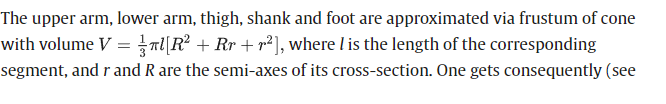
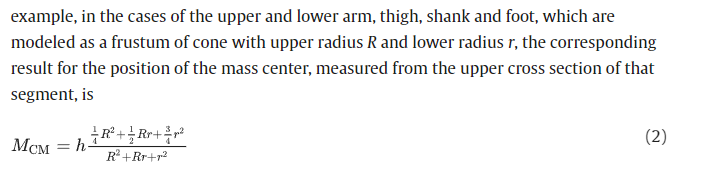

Reference:

Nikolova, Gergana Stefanova, and Yuli Emilov Toshev. "Estimation of male and female body segment parameters of the Bulgarian population using a 16-segmental mathematical model." Journal of biomechanics 40.16 (2007): 3700-3707.

Hanavan Jr, Ernest P. "A mathematical model of the human body." (1965). 



## 6. Shank
Input parameters : calf_circumference, ankle_circumference, shank_mass, shank (length) 

In [757]:
# Frustum parameters for shank
calf_circumference = 38.11171942 #cm
ankle_circumference = 22.58078373 #cm
shank_mass=3.1445993 #kg

In [758]:


calf_circumference = 38.11171942 #cm
ankle_circumference = 22.58078373 #cm
shank_mass=3.1445993 #kg

# Frustum parameters for upper arm
r1 =calf_circumference/(2 * math.pi)   # radius at one end
R1=r1
r2 =ankle_circumference/(2 * math.pi)  # radius at other end
R2=r2
h7 = shank_length   # height
mass = shank_mass


# Volume of frustum of frustum
volume_shank = (1/3) * np.pi * h7 * (r1**2 + r2**2 + r1*r2)
density = mass/volume_shank

# Center of mass
center_of_mass_shank_Y = calculate_center_of_mass(h7, r1, R1, r2, R2)
center_of_mass_shank_X = 0
center_of_mass_shank_Z = 0


# Inertia of frustum
Ixx_shank, Iyy_shank, Izz_shank = frustum_inertia(r1, R1, r2, R2, density, h7)

print(f"Shank -  Mass: {shank_mass:.2f}, Center of Mass(X): {center_of_mass_shank_X:.2f}, Center of Mass(Y): -{center_of_mass_shank_Y:.2f}, Center of Mass(Z): {center_of_mass_shank_Z:.2f}, Inertia: (Ixx: {Ixx_shank:.2f}, Iyy: {Iyy_shank:.2f}, Izz: {Izz_shank:.2f})")


Shank -  Mass: 3.14, Center of Mass(X): 0.00, Center of Mass(Y): -17.87, Center of Mass(Z): 0.00, Inertia: (Ixx: 470.34, Iyy: 40.62, Izz: 470.34)


## 7. foot

Input parameters (foot) : balloffoot_circumference, shnak_mass, ankle_height, foot (length) 

In [759]:
# Frustum parameters for foot
foot = 27.59313917 #cm
ankle_height = 7.434086377 #cm
balloffoot_circumference = 25.12666045#cm
foot_mass= 0.929429937 #kg

In [760]:


# Frustum parameters for upper arm
r1 =ankle_height/2    # radius at one end
R1=r1
r2 =balloffoot_circumference/(2 *np.pi)  # radius at other end
R2=r2
h8 = foot   # height
mass = foot_mass

# Volume of frustum
volume_foot = (1/3) * np.pi * h8 * (r1**2 + r2**2 + r1*r2)
density = mass/volume_foot

# Center of mass of frustum
center_of_mass_foot_X = calculate_center_of_mass(h8, r1, R1, r2, R2)-(h8/2)
center_of_mass_foot_Y = r1
center_of_mass_foot_Z = 0

# Inertia of frustum
Ixx_foot, Iyy_foot, Izz_foot = frustum_inertia(r1, R1, r2, R2, density, h8)

print(f"Foot - Mass: {foot_mass:.2f}, Center of Mass(X): {center_of_mass_foot_X:.2f}, Center of Mass(Y): -{center_of_mass_foot_Y:.2f}, Center of Mass(Z): {center_of_mass_foot_Z:.2f}, Inertia: (Ixx: {Iyy_foot:.2f}, Iyy: {Ixx_foot:.2f}, Izz: {Izz_foot:.2f})")



Foot - Mass: 0.93, Center of Mass(X): 0.34, Center of Mass(Y): -3.72, Center of Mass(Z): 0.00, Inertia: (Ixx: 6.93, Iyy: 62.35, Izz: 62.35)


## 8. Upper arm 

Input parameters: biceps_circumference, forearm_circumference, upperarm_mass, upperarm (length) 

In [761]:
# Frustum parameters for uppperarm
upperarm_length= 34.28636885 #cm
biceps_circumference = 34.2 #cm
forearm_circumference = 30.35756932 #cm
upperarm_mass=2.878196874 #kg


In [762]:

# Frustum parameters for upper arm
r1 =biceps_circumference/( 2*np.pi)   # radius at one end
R1=r1
r2 =forearm_circumference/( 2*np.pi)  # radius at other end
R2=r2
h9 = upperarm_length   # height
mass = upperarm_mass

# Volume of frustum
volume_upperarm = (1/3) * np.pi * h9 * (r1**2 + r2**2 + r1*r2)
density = mass/volume_upperarm

# Center of mass of frustum
center_of_mass_upperarm_Y = calculate_center_of_mass(h9, r1, R1, r2, R2)
center_of_mass_upperarm_X = 0
center_of_mass_upperarm_Z = 0 
# Inertia of frustum
Ixx_upperarm, Iyy_upperarm, Izz_upperarm = frustum_inertia(r1, R1, r2, R2, density, h9)

print(f"Upper Arm -  Mass: {upperarm_mass:.2f}, Center of Mass(X): {center_of_mass_upperarm_X:.2f}, Center of Mass(Y): -{center_of_mass_upperarm_Y:.2f}, Center of Mass(Z): {center_of_mass_upperarm_Z:.2f},  Inertia: (Ixx: {Ixx_upperarm:.2f}, Iyy: {Iyy_upperarm:.2f}, Izz: {Izz_upperarm:.2f})")


Upper Arm -  Mass: 2.88, Center of Mass(X): 0.00, Center of Mass(Y): -16.46, Center of Mass(Z): 0.00,  Inertia: (Ixx: 300.00, Iyy: 38.20, Izz: 300.00)


## 9. Forearm

Input parameters : forearm_circumference, wrist_circumference, forearm_mass, forearm (length) 

In [763]:
# Frustum parameters for forearm
forearm = 29.33639148 #cm
forearm_circumference = 30.35756932 #cm
wrist_circumference = 17.50775304 #cm
forearm_mass=1.633991062 #kg

In [764]:

# Frustum parameters for lower arm
r1 =forearm_circumference/(2 * math.pi)   # radius at one end
R1=r1
r2 =wrist_circumference/(2 * math.pi)  # radius at other end
R2=r2
h10 = forearm   # height
mass = forearm_mass


# Volume of frustum
volume_forearm = (1/3) * np.pi * h10 * (r1**2 + r2**2 + r1*r2)
density = mass/volume_forearm

# Center of mass of frustum
center_of_mass_forearm_Y = calculate_center_of_mass(h10, r1, R1, r2, R2)
center_of_mass_forearm_X = 0
center_of_mass_forearm_Z = 0
# Inertia of frustum
Ixx_forearm, Iyy_forearm, Izz_forearm = frustum_inertia(r1, R1, r2, R2, density, h10)

print(f"Forearm - Mass: {forearm_mass:.2f}, Center of Mass(X): {center_of_mass_forearm_X:.2f}, Center of Mass(Y): -{center_of_mass_forearm_Y:.2f}, Center of Mass(Z): {center_of_mass_forearm_Z:.2f}, Inertia: (Ixx: {Ixx_forearm:.2f}, Iyy: {Iyy_forearm:.2f}, Izz: {Izz_forearm:.2f})")

Forearm - Mass: 1.63, Center of Mass(X): 0.00, Center of Mass(Y): -12.10, Center of Mass(Z): 0.00, Inertia: (Ixx: 115.28, Iyy: 13.26, Izz: 115.28)


## 10. Hand 

Input parameters : hand (length), hand_mass

In [765]:

Hand_length=19.64172797
hand_mass = 0.656703408
r = Hand_length/4 # Hand length
R = r
h= R
m=hand_mass
# Center of mass of sphere (at the center)
center_of_mass_hand_Y =  0
center_of_mass_hand_Z =  0
center_of_mass_hand_X =  0

# Inertia of ellipsoid

Ixx_hand_obese, Iyy_hand_obese, Izz_hand_obese = ellipsoid_inertia (R, r, h, m)
print(f"Hand - Mass: {hand_mass:.2f}, Center of Mass(X): {center_of_mass_hand_X:.2f}, Center of Mass (Y): {center_of_mass_hand_Y:.2f}, Center of Mass (Z): {center_of_mass_hand_Z:.2f}, Inertia (Ixx: {Ixx_hand_obese:.2f}, Iyy: {Iyy_hand_obese:.2f}, Izz: {Izz_hand_obese:.2f})")

Hand - Mass: 0.66, Center of Mass(X): 0.00, Center of Mass (Y): 0.00, Center of Mass (Z): 0.00, Inertia (Ixx: 6.33, Iyy: 6.33, Izz: 6.33)


#Result

In [766]:
print(f"Head and Neck - Mass: {head_mass:.2f}, Center of Mass(X): {center_of_mass_head_X}, Center of Mass(Y): {center_of_mass_head_Y}, Center of Mass(Z): {center_of_mass_head_Z},(Ixx: {Ixx_head}, Iyy: {Iyy_head}, Izz: {Izz_head})")
# Print the formatted results
print(f"Upper Torso -  Mass: {uppertorso_mass:.2f}, "
      f"Center of Mass(X): {center_of_mass_uppertorso_X:.2f}, "
      f"Center of Mass(Y): -{center_of_mass_uppertorso_Y:.2f}, "
      f"Center of Mass(Z): {center_of_mass_uppertorso_Z:.2f}, "
      f"Inertia: (Ixx: {Ixx_uppertorso:.2f}, "
      f"Iyy: {Iyy_uppertorso:.2f}, "
      f"Izz: {Izz_uppertorso:.2f})")
print(f"Middle Torso - Mass: {middletorso_mass:.2f},Center of Mass(X): {center_of_mass_middletorso_X:.2f}, Center of Mass(Y): -{center_of_mass_middletorso_Y:.2f}, Center of Mass(Z): {center_of_mass_middletorso_Z:.2f}, Inertia: (Ixx: {Ixx_middletorso:.2f}, Iyy: {Iyy_middletorso:.2f}, Izz: {Izz_middletorso:.2f})")

# Print the formatted results
print(f"Lower Torso -  Mass: {lowertorso_mass_obese:.2f}, "
      f"Center of Mass(X): {center_of_mass_lowertorso_obese_X:.2f}, "
      f"Center of Mass(Y): -{center_of_mass_lowertorso_obese_Y:.2f}, "
      f"Center of Mass(Z): {center_of_mass_lowertorso_obese_Z:.2f}, "
      f"Inertia: (Ixx: {Ixx_lowertorso_obese:.2f}, "
      f"Iyy: {Iyy_lowertorso_obese:.2f}, "
      f"Izz: {Izz_lowertorso_obese:.2f})")
# Print the formatted results
print(f"Thigh -  Mass: {thigh_mass:.2f}, "
      f"Center of Mass(X): {center_of_mass_thigh_X:.2f}, "
      f"Center of Mass(Y): -{center_of_mass_thigh_Y:.2f}, "
      f"Center of Mass(Z): {center_of_mass_thigh_Z:.2f}, "
      f"Inertia: (Ixx: {Ixx_thigh:.2f}, "
      f"Iyy: {Iyy_thigh:.2f}, "
      f"Izz: {Izz_thigh:.2f})")

print(f"Shank -  Mass: {shank_mass:.2f}, Center of Mass(X): {center_of_mass_shank_X:.2f}, Center of Mass(Y): -{center_of_mass_shank_Y:.2f}, Center of Mass(Z): {center_of_mass_shank_Z:.2f}, Inertia: (Ixx: {Ixx_shank:.2f}, Iyy: {Iyy_shank:.2f}, Izz: {Izz_shank:.2f})")
print(f"Foot - Mass: {foot_mass:.2f}, Center of Mass(X): {center_of_mass_foot_X:.2f}, Center of Mass(Y): -{center_of_mass_foot_Y:.2f}, Center of Mass(Z): {center_of_mass_foot_Z:.2f}, Inertia: (Ixx: {Iyy_foot:.2f}, Iyy: {Ixx_foot:.2f}, Izz: {Izz_foot:.2f})")
print(f"Upper Arm - Mass: {upperarm_mass:.2f}, Center of Mass(X): {center_of_mass_upperarm_X:.2f}, Center of Mass(Y): -{center_of_mass_upperarm_Y:.2f}, Center of Mass(Z): {center_of_mass_upperarm_Z:.2f},  Inertia: (Ixx: {Ixx_upperarm:.2f}, Iyy: {Iyy_upperarm:.2f}, Izz: {Izz_upperarm:.2f})")
print(f"Forearm - Mass: {forearm_mass:.2f}, Center of Mass(X): {center_of_mass_forearm_X:.2f}, Center of Mass(Y): -{center_of_mass_forearm_Y:.2f}, Center of Mass(Z): {center_of_mass_forearm_Z:.2f}, Inertia: (Ixx: {Ixx_forearm:.2f}, Iyy: {Iyy_forearm:.2f}, Izz: {Izz_forearm:.2f})")
print(f"Hand - Mass: {hand_mass:.2f}, Center of Mass(X): {center_of_mass_hand_X:.2f}, Center of Mass (Y): {center_of_mass_hand_Y:.2f}, Center of Mass (Z): {center_of_mass_hand_Z:.2f}, Inertia (Ixx: {Ixx_hand_obese:.2f}, Iyy: {Iyy_hand_obese:.2f}, Izz: {Izz_hand_obese:.2f})")

Head and Neck - Mass: 5.07, Center of Mass(X): 0, Center of Mass(Y): 0, Center of Mass(Z): 0,(Ixx: 234.02466755212734, Iyy: 168.8398883349738, Izz: 234.02466755212734)
Upper Torso -  Mass: 15.68, Center of Mass(X): 0.00, Center of Mass(Y): -12.59, Center of Mass(Z): 0.00, Inertia: (Ixx: 1730.68, Iyy: 1710.69, Izz: 1064.94)
Middle Torso - Mass: 10.83,Center of Mass(X): 0.00, Center of Mass(Y): -11.79, Center of Mass(Z): 0.00, Inertia: (Ixx: 1105.85, Iyy: 954.95, Izz: 861.35)
Lower Torso -  Mass: 11.31, Center of Mass(X): 0.00, Center of Mass(Y): -9.47, Center of Mass(Z): 0.00, Inertia: (Ixx: 1182.76, Iyy: 1131.10, Izz: 737.78)
Thigh -  Mass: 9.31, Center of Mass(X): 0.00, Center of Mass(Y): -11.38, Center of Mass(Z): 0.14, Inertia: (Ixx: 1282.54, Iyy: 321.23, Izz: 1276.40)
Shank -  Mass: 3.14, Center of Mass(X): 0.00, Center of Mass(Y): -17.87, Center of Mass(Z): 0.00, Inertia: (Ixx: 470.34, Iyy: 40.62, Izz: 470.34)
Foot - Mass: 0.93, Center of Mass(X): 0.34, Center of Mass(Y): -3.72, C